# Week 4: Statistical Inference for Two Populations and Categorical Data

## Module Overview

Welcome to Week 4! In this module, we extend our statistical inference knowledge from single populations to comparing **two populations** and analyzing **categorical data**.

### What We'll Learn:

1. **Comparing Two Population Means**
   - Independent samples (using Welch's t-test)
   - Paired/Dependent samples

2. **Comparing Two Population Variances**
   - F-test for testing consistency and variability

3. **Testing Population Proportions**
   - One-sample proportion test
   - Two-sample proportion test

4. **Chi-Square Test of Independence**
   - Testing relationships between categorical variables

### Why This Matters:

These methods are essential for:
- **Medical Research**: Comparing treatment effectiveness
- **Business**: A/B testing, quality control
- **Education**: Comparing teaching methods
- **Manufacturing**: Testing machine consistency
- **Marketing**: Analyzing customer preferences

Let's dive in! 🚀


---
## Setup: Import Libraries

First, let's import all the necessary libraries for our analysis.


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Setup Complete! All libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


Setup Complete! All libraries loaded successfully.
NumPy version: 2.0.2
Pandas version: 2.2.2


---
## Section 1: Comparing Two Population Means - Independent Samples

### The Fundamental Question

**Are two groups significantly different?**

This is one of the most common questions in statistics:

- 🏥 **Medical**: Is Drug A more effective than Drug B?
- 📚 **Education**: Do students from School A perform better than School B?
- 💼 **Business**: Do customers prefer Product X over Product Y?
- 🏭 **Manufacturing**: Does Machine 1 produce different parts than Machine 2?

### Independent vs Paired Samples

Before analyzing, we must determine the **nature of our samples**:

#### 🔹 Independent Samples
- Two **separate, unrelated groups**
- No natural pairing between observations
- Examples:
  - Heights of people from Kashmir vs Lucknow
  - Salaries of engineering vs arts graduates
  - Online vs offline book prices

#### 🔹 Paired (Dependent) Samples
- **Same subjects** measured twice
- Natural pairing exists
- Examples:
  - Weight before and after diet
  - Blood pressure before and after medication
  - Test scores before and after tutoring

---

### Welch's Two-Sample t-test (Unequal Variances)

For independent samples where we **cannot assume equal variances**, we use **Welch's t-test**.

**Why Welch's t-test?**
- ✅ More robust - doesn't require equal variance assumption
- ✅ Modern standard approach
- ✅ Works well even when sample sizes differ
- ✅ Conservative and reliable

#### Test Statistic:

$$t = \frac{(\bar{x}_1 - \bar{x}_2) - 0}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

**Where:**
- $\bar{x}_1, \bar{x}_2$ = sample means of groups 1 and 2
- $s_1^2, s_2^2$ = sample variances of groups 1 and 2
- $n_1, n_2$ = sample sizes of groups 1 and 2
- The 0 in numerator assumes null hypothesis: $\mu_1 - \mu_2 = 0$

**Degrees of Freedom (Welch-Satterthwaite):**

$$df = \frac{\left(\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1} + \frac{(s_2^2/n_2)^2}{n_2-1}}$$

**Key Feature:** Each group's variance is used **separately** - no assumption about equal population variances!

---

### Hypothesis Testing Framework

**Step 1: State Hypotheses**
- $H_0$: $\mu_1 = \mu_2$ (No difference between groups)
- $H_a$: $\mu_1 \neq \mu_2$ (Groups are different)

**Step 2: Set Significance Level**
- Typically $\alpha = 0.05$

**Step 3: Calculate Test Statistic**
- Compute t-statistic using Welch's formula

**Step 4: Make Decision**
- If $p$-value < $\alpha$: Reject $H_0$ (groups are significantly different)
- If $p$-value ≥ $\alpha$: Fail to reject $H_0$ (no significant difference)


---
### 📊 Example 1: Online vs Offline Teaching Methods

**Scenario**: A university wants to compare exam scores between online and offline teaching methods.

**Question**: Is there a significant difference in student performance?


In [ ]:
print("="*80)
print("SCENARIO: Comparing Online vs Offline Teaching Methods")
print("="*80)
print()

# Generate sample data
np.random.seed(42)
n_online = 30
n_offline = 35

# Online students (slightly higher mean, more variable)
online_scores = np.random.normal(loc=78, scale=12, size=n_online)
online_scores = np.clip(online_scores, 0, 100)

# Offline students
offline_scores = np.random.normal(loc=73, scale=10, size=n_offline)
offline_scores = np.clip(offline_scores, 0, 100)

# Calculate descriptive statistics
mean_online = np.mean(online_scores)
mean_offline = np.mean(offline_scores)
std_online = np.std(online_scores, ddof=1)
std_offline = np.std(offline_scores, ddof=1)

print("DESCRIPTIVE STATISTICS:")
print("-"*80)
print(f"Online Teaching (n={n_online}):")
print(f"  Mean: {mean_online:.2f}")
print(f"  Std Dev: {std_online:.2f}")
print(f"  Range: [{np.min(online_scores):.2f}, {np.max(online_scores):.2f}]")
print()
print(f"Offline Teaching (n={n_offline}):")
print(f"  Mean: {mean_offline:.2f}")
print(f"  Std Dev: {std_offline:.2f}")
print(f"  Range: [{np.min(offline_scores):.2f}, {np.max(offline_scores):.2f}]")
print()
print(f"Difference in means: {mean_online - mean_offline:.2f}")
print(f"Ratio of variances: {(std_online**2)/(std_offline**2):.2f}")
print("="*80)


SCENARIO: Comparing Online vs Offline Teaching Methods

DESCRIPTIVE STATISTICS:
--------------------------------------------------------------------------------
Online Teaching (n=30):
  Mean: 75.74
  Std Dev: 10.80
  Range: [55.04, 96.95]

Offline Teaching (n=35):
  Mean: 71.35
  Std Dev: 9.11
  Range: [53.40, 91.52]

Difference in means: 4.40
Ratio of variances: 1.41


In [ ]:
# Perform Welch's t-test (unequal variances)
print("\nHYPOTHESIS TEST: Welch's Two-Sample t-test")
print("-"*80)
print()

# Step 1: State hypotheses
print("Step 1: State Hypotheses")
print("  H₀: μ_online = μ_offline (No difference in mean scores)")
print("  Hₐ: μ_online ≠ μ_offline (Means are different)")
print()

# Step 2: Set significance level
alpha = 0.05
print(f"Step 2: Set Significance Level: α = {alpha}")
print()

# Step 3: Perform Welch's t-test
# equal_var=False specifies Welch's t-test
t_stat, p_value = stats.ttest_ind(online_scores, offline_scores, equal_var=False)

# Manual calculation for educational purposes
se_diff = np.sqrt((std_online**2 / n_online) + (std_offline**2 / n_offline))
t_manual = (mean_online - mean_offline) / se_diff

# Welch-Satterthwaite degrees of freedom
df = ((std_online**2 / n_online + std_offline**2 / n_offline)**2 /
      ((std_online**2 / n_online)**2 / (n_online - 1) +
       (std_offline**2 / n_offline)**2 / (n_offline - 1)))

print("Step 3: Calculate Test Statistic (Welch's Method)")
print(f"  Standard Error: {se_diff:.3f}")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  Degrees of freedom: {df:.2f}")
print()

# Step 4: Make decision
print("Step 4: Make Decision")
print(f"  p-value: {p_value:.4f}")
print(f"  Decision: ", end="")
if p_value < alpha:
    print(f"REJECT H₀ (p = {p_value:.4f} < α = {alpha})")
    print("  Conclusion: There IS a significant difference between teaching methods! ✓")
else:
    print(f"FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print("  Conclusion: No significant difference between teaching methods")

# Calculate confidence interval
ci = stats.t.interval(0.95, df, loc=mean_online - mean_offline, scale=se_diff)
print()
print(f"95% Confidence Interval for difference: ({ci[0]:.2f}, {ci[1]:.2f})")
print()

# Effect size (Cohen's d)
pooled_std = np.sqrt(((n_online - 1) * std_online**2 + (n_offline - 1) * std_offline**2) /
                     (n_online + n_offline - 2))
cohen_d = (mean_online - mean_offline) / pooled_std
print(f"Effect size (Cohen's d): {cohen_d:.3f}")
if abs(cohen_d) < 0.2:
    effect = "negligible"
elif abs(cohen_d) < 0.5:
    effect = "small"
elif abs(cohen_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"Interpretation: {effect.upper()} effect")
print("="*80)



HYPOTHESIS TEST: Welch's Two-Sample t-test
--------------------------------------------------------------------------------

Step 1: State Hypotheses
  H₀: μ_online = μ_offline (No difference in mean scores)
  Hₐ: μ_online ≠ μ_offline (Means are different)

Step 2: Set Significance Level: α = 0.05

Step 3: Calculate Test Statistic (Welch's Method)
  Standard Error: 2.502
  t-statistic: 1.757
  Degrees of freedom: 57.05

Step 4: Make Decision
  p-value: 0.0842
  Decision: FAIL TO REJECT H₀ (p = 0.0842 ≥ α = 0.05)
  Conclusion: No significant difference between teaching methods

95% Confidence Interval for difference: (-0.61, 9.41)

Effect size (Cohen's d): 0.443
Interpretation: SMALL effect


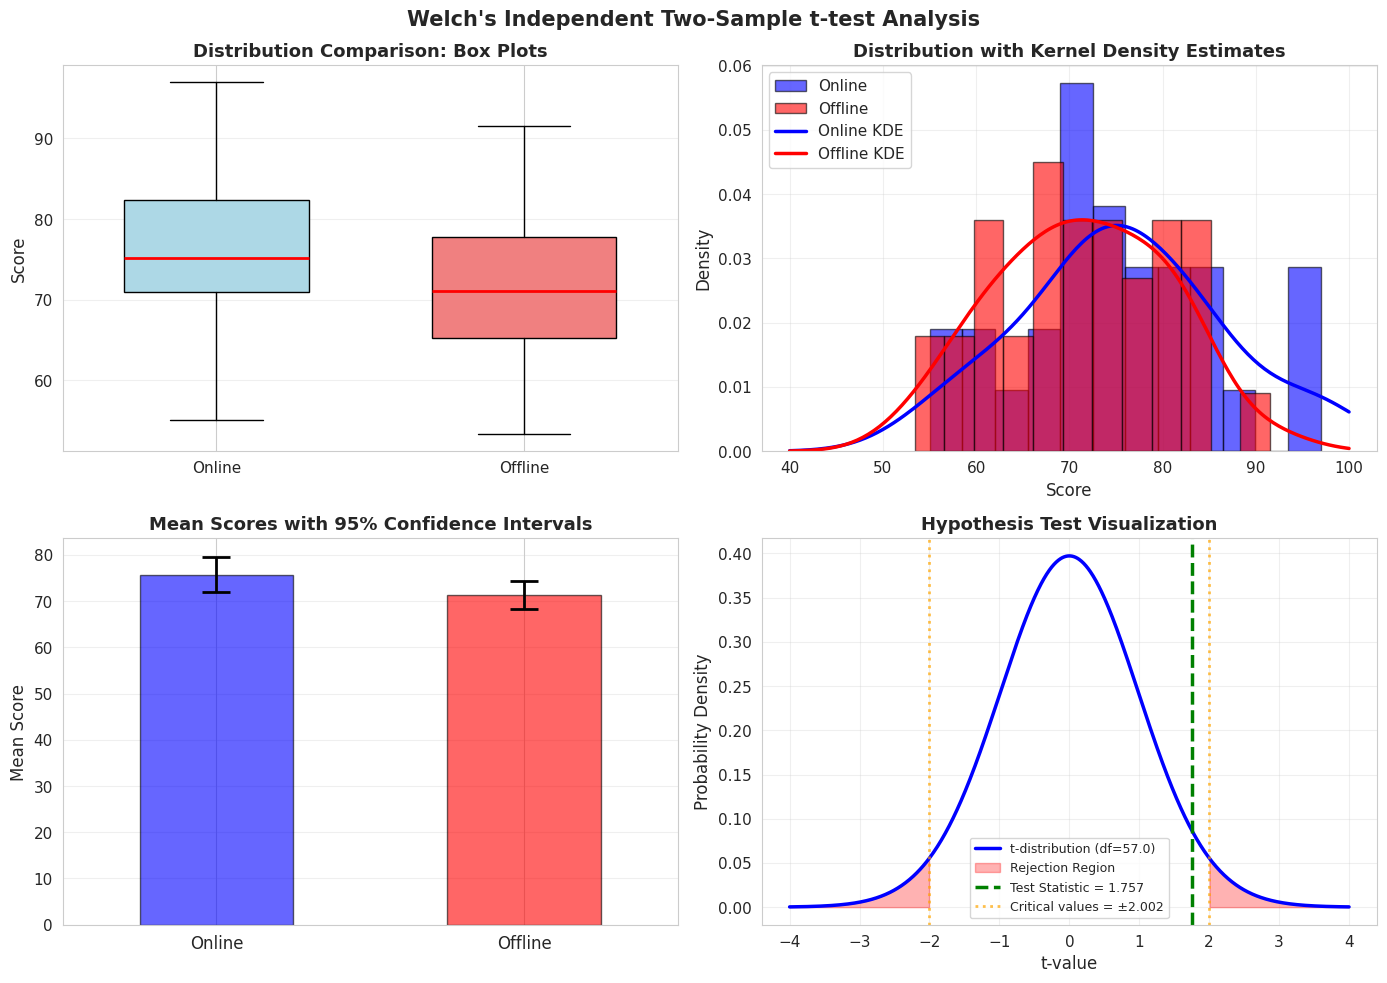

In [ ]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plots
ax1 = axes[0, 0]
bp = ax1.boxplot([online_scores, offline_scores], labels=['Online', 'Offline'],
                  patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
for median in bp['medians']:
    median.set(color='red', linewidth=2)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Distribution Comparison: Box Plots', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Histograms with KDE
ax2 = axes[0, 1]
ax2.hist(online_scores, bins=12, alpha=0.6, label='Online', color='blue', density=True, edgecolor='black')
ax2.hist(offline_scores, bins=12, alpha=0.6, label='Offline', color='red', density=True, edgecolor='black')

from scipy.stats import gaussian_kde
kde_online = gaussian_kde(online_scores)
kde_offline = gaussian_kde(offline_scores)
x_range = np.linspace(40, 100, 200)
ax2.plot(x_range, kde_online(x_range), 'b-', linewidth=2.5, label='Online KDE')
ax2.plot(x_range, kde_offline(x_range), 'r-', linewidth=2.5, label='Offline KDE')
ax2.set_xlabel('Score', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution with Kernel Density Estimates', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# 3. Means with Confidence Intervals
ax3 = axes[1, 0]
means = [mean_online, mean_offline]
errors = [std_online / np.sqrt(n_online), std_offline / np.sqrt(n_offline)]
x_pos = [1, 2]
colors = ['blue', 'red']
ax3.bar(x_pos, means, color=colors, alpha=0.6, edgecolor='black', width=0.5)
ax3.errorbar(x_pos, means, yerr=[e * 1.96 for e in errors], fmt='none',
             capsize=10, capthick=2, color='black', elinewidth=2)
ax3.set_xlim(0.5, 2.5)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Online', 'Offline'], fontsize=12)
ax3.set_ylabel('Mean Score', fontsize=12)
ax3.set_title('Mean Scores with 95% Confidence Intervals', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 4. t-distribution
ax4 = axes[1, 1]
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)
ax4.plot(x, y, 'b-', linewidth=2.5, label=f't-distribution (df={df:.1f})')

t_crit = stats.t.ppf(1 - alpha/2, df)
ax4.fill_between(x, y, where=(x <= -t_crit), alpha=0.3, color='red', label='Rejection Region')
ax4.fill_between(x, y, where=(x >= t_crit), alpha=0.3, color='red')
ax4.axvline(t_stat, color='green', linestyle='--', linewidth=2.5,
            label=f'Test Statistic = {t_stat:.3f}')
ax4.axvline(-t_crit, color='orange', linestyle=':', linewidth=2, alpha=0.7)
ax4.axvline(t_crit, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'Critical values = ±{t_crit:.3f}')
ax4.set_xlabel('t-value', fontsize=12)
ax4.set_ylabel('Probability Density', fontsize=12)
ax4.set_title('Hypothesis Test Visualization', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle('Welch\'s Independent Two-Sample t-test Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 2: Paired (Dependent) Samples t-test

### When to Use Paired Tests

Paired tests are used when:
- ✅ The **same subjects** are measured twice
- ✅ There's a **natural pairing** between observations
- ✅ We're interested in the **change** or **difference**

### Examples of Paired Data:

1. **Before-After Studies**:
   - Weight before and after diet program
   - Blood pressure before and after medication
   - Test scores before and after tutoring

2. **Matched Pairs**:
   - Left vs right hand performance
   - Twin studies
   - Product testing on same individuals

### The Mathematics

For paired samples, we work with the **differences**:

$$d_i = x_{1i} - x_{2i}$$

**Test Statistic:**

$$t = \frac{\bar{d} - \mu_d}{s_d / \sqrt{n}}$$

**Where:**
- $\bar{d}$ = mean of differences
- $s_d$ = standard deviation of differences
- $n$ = number of pairs
- $\mu_d$ = hypothesized mean difference (usually 0)

**Degrees of Freedom:** $df = n - 1$

---

### Why Paired Tests Are More Powerful

By focusing on **within-subject differences**, paired tests:
- 📉 Reduce variability (each person is their own control)
- 📈 Increase statistical power
- 🎯 Better detect small effects


---
### 📊 Example 2: Weight Loss Program Evaluation

**Scenario**: A fitness company wants to evaluate the effectiveness of their new weight loss program.

**Question**: Does the program lead to significant weight loss?


In [ ]:
print("="*80)
print("SCENARIO: Evaluating a Weight Loss Program")
print("="*80)
print()

# Generate paired data (same people, before and after)
np.random.seed(42)
n_participants = 20

# Before weights (kg)
weights_before = np.random.normal(loc=85, scale=12, size=n_participants)
weights_before = np.clip(weights_before, 60, 120)

# After weights (average 3kg loss with individual variation)
weight_loss = np.random.normal(loc=3, scale=2, size=n_participants)
weights_after = weights_before - weight_loss
weights_after = np.clip(weights_after, 55, 115)

# Create DataFrame
df_weights = pd.DataFrame({
    'Participant': range(1, n_participants + 1),
    'Before (kg)': weights_before,
    'After (kg)': weights_after,
    'Loss (kg)': weights_before - weights_after
})

print("SAMPLE DATA (first 10 participants):")
print("-"*80)
print(df_weights.head(10).to_string(index=False))
print()

print("SUMMARY STATISTICS:")
print("-"*80)
print(f"Mean weight before: {weights_before.mean():.2f} kg")
print(f"Mean weight after: {weights_after.mean():.2f} kg")
print(f"Mean weight loss: {df_weights['Loss (kg)'].mean():.2f} kg")
print(f"Std dev of weight loss: {df_weights['Loss (kg)'].std():.2f} kg")
print(f"Min loss: {df_weights['Loss (kg)'].min():.2f} kg")
print(f"Max loss: {df_weights['Loss (kg)'].max():.2f} kg")
print("="*80)


SCENARIO: Evaluating a Weight Loss Program

SAMPLE DATA (first 10 participants):
--------------------------------------------------------------------------------
 Participant  Before (kg)  After (kg)  Loss (kg)
           1    90.960570   85.029272   5.931298
           2    83.340828   80.792381   2.548447
           3    92.772262   89.637206   3.135056
           4   103.276358  103.125855   0.150504
           5    82.190160   80.278925   1.911235
           6    82.190357   78.968511   3.221845
           7   103.950554  103.252541   0.698013
           8    94.209217   90.457821   3.751396
           9    79.366307   77.567585   1.798723
          10    91.510721   89.094108   2.416613

SUMMARY STATISTICS:
--------------------------------------------------------------------------------
Mean weight before: 82.94 kg
Mean weight after: 80.48 kg
Mean weight loss: 2.47 kg
Std dev of weight loss: 1.94 kg
Min loss: -0.92 kg
Max loss: 6.70 kg


In [ ]:
# Hypothesis Test: Paired t-test
print("\nHYPOTHESIS TEST: Paired t-test")
print("-"*80)
print()

# Step 1: State hypotheses
print("Step 1: State Hypotheses")
print("  H₀: μ_d = 0 (No weight change)")
print("  Hₐ: μ_d > 0 (Weight loss occurred)")
print("  Note: This is a ONE-TAILED test (we expect loss, not gain)")
print()

# Step 2: Set significance level
alpha = 0.05
print(f"Step 2: Set Significance Level: α = {alpha}")
print()

# Step 3: Perform paired t-test
t_stat, p_value_two_tailed = stats.ttest_rel(weights_before, weights_after)
p_value_one_tailed = p_value_two_tailed / 2  # Convert to one-tailed

# Manual calculation
differences = weights_before - weights_after
d_bar = np.mean(differences)
s_d = np.std(differences, ddof=1)
se_d = s_d / np.sqrt(n_participants)
t_manual = d_bar / se_d
df = n_participants - 1

print("Step 3: Calculate Test Statistic")
print(f"  Mean difference (d̄): {d_bar:.3f} kg")
print(f"  Std dev of differences (s_d): {s_d:.3f} kg")
print(f"  Standard error (SE): {se_d:.3f}")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  Degrees of freedom: {df}")
print()

# Step 4: Make decision
print("Step 4: Make Decision")
print(f"  p-value (one-tailed): {p_value_one_tailed:.4f}")
if p_value_one_tailed < alpha:
    print(f"  Decision: REJECT H₀ (p = {p_value_one_tailed:.4f} < α = {alpha})")
    print("  Conclusion: The weight loss program IS effective! ✓")
    print(f"  Average weight loss: {d_bar:.2f} kg")
else:
    print(f"  Decision: FAIL TO REJECT H₀ (p = {p_value_one_tailed:.4f} ≥ α = {alpha})")
    print("  Conclusion: No significant weight loss detected")

# Confidence interval
ci = stats.t.interval(0.95, df, loc=d_bar, scale=se_d)
print()
print(f"95% CI for mean weight loss: ({ci[0]:.2f}, {ci[1]:.2f}) kg")

# Effect size
cohen_d = d_bar / s_d
print()
print(f"Effect size (Cohen's d): {cohen_d:.3f}")
if abs(cohen_d) < 0.2:
    effect = "negligible"
elif abs(cohen_d) < 0.5:
    effect = "small"
elif abs(cohen_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"Interpretation: {effect.upper()} effect")
print("="*80)



HYPOTHESIS TEST: Paired t-test
--------------------------------------------------------------------------------

Step 1: State Hypotheses
  H₀: μ_d = 0 (No weight change)
  Hₐ: μ_d > 0 (Weight loss occurred)
  Note: This is a ONE-TAILED test (we expect loss, not gain)

Step 2: Set Significance Level: α = 0.05

Step 3: Calculate Test Statistic
  Mean difference (d̄): 2.468 kg
  Std dev of differences (s_d): 1.936 kg
  Standard error (SE): 0.433
  t-statistic: 5.701
  Degrees of freedom: 19

Step 4: Make Decision
  p-value (one-tailed): 0.0000
  Decision: REJECT H₀ (p = 0.0000 < α = 0.05)
  Conclusion: The weight loss program IS effective! ✓
  Average weight loss: 2.47 kg

95% CI for mean weight loss: (1.56, 3.37) kg

Effect size (Cohen's d): 1.275
Interpretation: LARGE effect


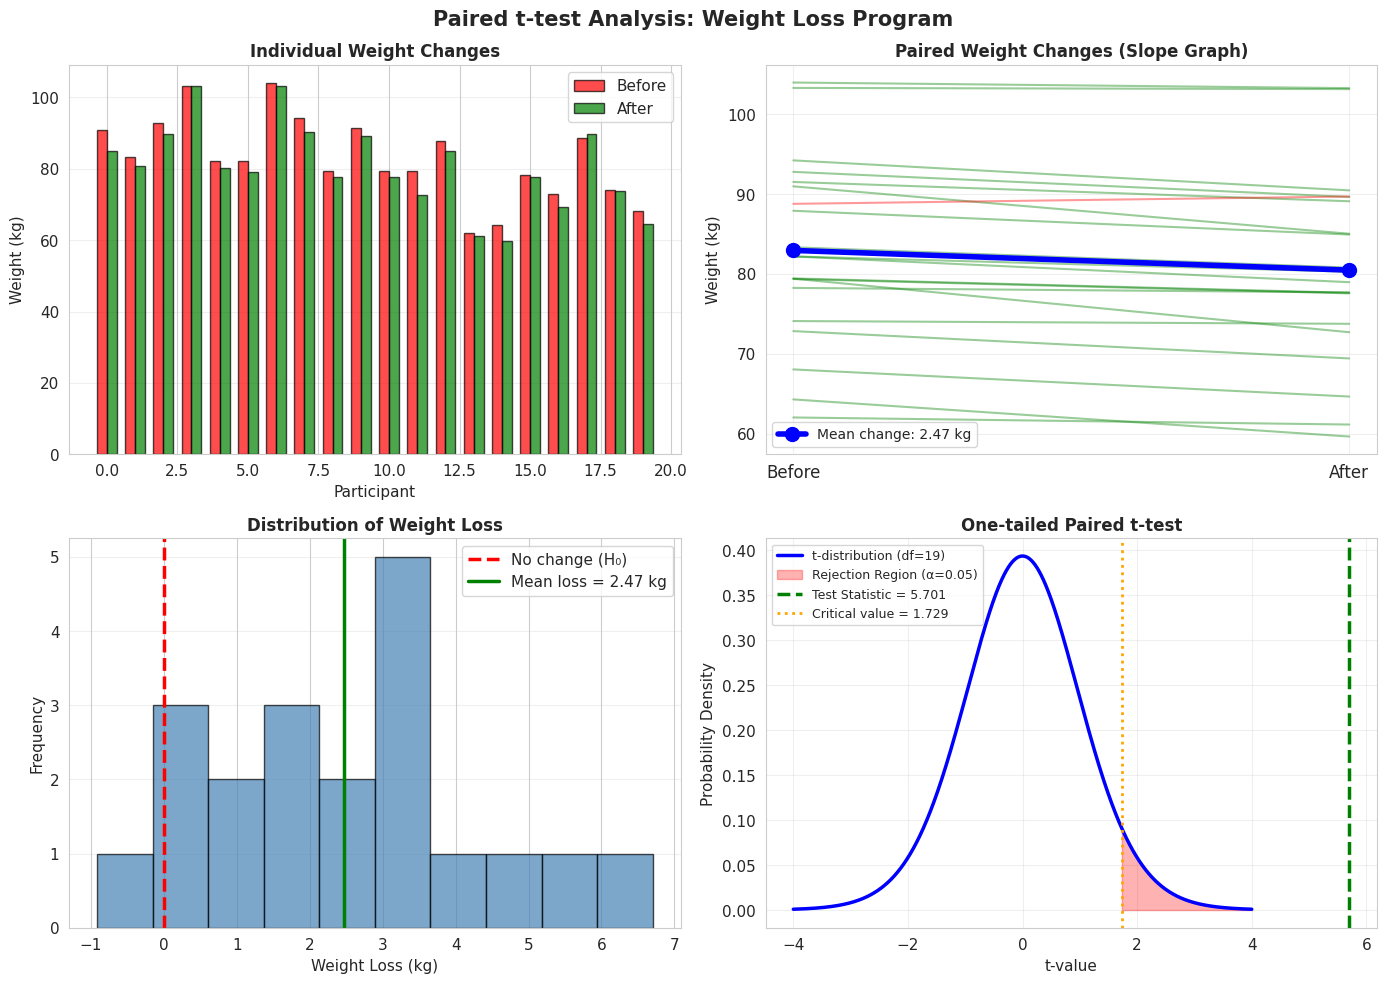

In [ ]:
# Visualization for Paired t-test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Before vs After for each participant
ax1 = axes[0, 0]
x_pos = np.arange(n_participants)
width = 0.35
bars1 = ax1.bar(x_pos - width/2, weights_before, width, label='Before',
                alpha=0.7, color='red', edgecolor='black')
bars2 = ax1.bar(x_pos + width/2, weights_after, width, label='After',
                alpha=0.7, color='green', edgecolor='black')
ax1.set_xlabel('Participant', fontsize=11)
ax1.set_ylabel('Weight (kg)', fontsize=11)
ax1.set_title('Individual Weight Changes', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Paired plot (slope graph)
ax2 = axes[0, 1]
for i in range(n_participants):
    color = 'green' if weights_before[i] > weights_after[i] else 'red'
    ax2.plot([0, 1], [weights_before[i], weights_after[i]], color=color, alpha=0.4, linewidth=1.5)
ax2.plot([0, 1], [weights_before.mean(), weights_after.mean()], 'b-',
         linewidth=4, label=f'Mean change: {d_bar:.2f} kg', marker='o', markersize=10)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'], fontsize=12)
ax2.set_ylabel('Weight (kg)', fontsize=11)
ax2.set_title('Paired Weight Changes (Slope Graph)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. Distribution of differences
ax3 = axes[1, 0]
ax3.hist(differences, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(0, color='red', linestyle='--', linewidth=2.5, label='No change (H₀)')
ax3.axvline(d_bar, color='green', linestyle='-', linewidth=2.5,
            label=f'Mean loss = {d_bar:.2f} kg')
ax3.set_xlabel('Weight Loss (kg)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of Weight Loss', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. t-distribution with test statistic
ax4 = axes[1, 1]
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)
ax4.plot(x, y, 'b-', linewidth=2.5, label=f't-distribution (df={df})')
t_crit = stats.t.ppf(1 - alpha, df)
ax4.fill_between(x, y, where=(x >= t_crit), alpha=0.3, color='red',
                  label=f'Rejection Region (α={alpha})')
ax4.axvline(t_stat, color='green', linestyle='--', linewidth=2.5,
            label=f'Test Statistic = {t_stat:.3f}')
ax4.axvline(t_crit, color='orange', linestyle=':', linewidth=2,
            label=f'Critical value = {t_crit:.3f}')
ax4.set_xlabel('t-value', fontsize=11)
ax4.set_ylabel('Probability Density', fontsize=11)
ax4.set_title('One-tailed Paired t-test', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle('Paired t-test Analysis: Weight Loss Program', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 3: Comparing Two Population Variances (F-test)

### Why Compare Variances?

While means tell us about **central tendency**, variance tells us about **consistency and reliability**:

- 🏭 **Manufacturing**: Which machine produces more consistent products?
- 💰 **Finance**: Which investment has more stable returns?
- 📚 **Education**: Which teaching method produces more uniform results?
- 🎯 **Quality Control**: Is process variability within acceptable limits?

**Key Insight**: Sometimes **variability matters more than average**!

---

### The F-test

The F-test compares the **ratio** of two variances:

$$F = \frac{s_1^2}{s_2^2}$$

**Convention**: Place the **larger variance** in the numerator (so $F \geq 1$)

#### F-Distribution Properties:

- ✅ Always positive ($F > 0$)
- ✅ Depends on **two degrees of freedom**:
  - $df_1 = n_1 - 1$ (numerator)
  - $df_2 = n_2 - 1$ (denominator)
- ✅ If variances are equal: $F \approx 1$
- ✅ If variances differ significantly: $F \gg 1$

---

### Hypothesis Framework

**Step 1: Hypotheses**
- $H_0$: $\sigma_1^2 = \sigma_2^2$ (Variances are equal)
- $H_a$: $\sigma_1^2 \neq \sigma_2^2$ (Variances are different)

**Step 2: Test Statistic**

$$F = \frac{s_{larger}^2}{s_{smaller}^2}$$

**Step 3: Decision Rule**
- If $F$ is close to 1: No significant difference
- If $F$ is large: Significant difference in variability


---
### 📊 Example 3: Machine Precision Comparison

**Scenario**: A factory has two machines producing ball bearings. Both produce parts with the same average diameter, but we want to know which machine is more **consistent**.

**Question**: Do the machines have different precision levels (variability)?


In [ ]:
print("="*80)
print("SCENARIO: Comparing Precision of Two Manufacturing Machines")
print("="*80)
print()

# Generate data with different variances
np.random.seed(42)

# Machine A: More consistent (lower variance)
n_a = 25
machine_a = np.random.normal(loc=10.0, scale=0.15, size=n_a)

# Machine B: Less consistent (higher variance)
n_b = 25
machine_b = np.random.normal(loc=10.0, scale=0.25, size=n_b)

# Calculate statistics
mean_a = np.mean(machine_a)
mean_b = np.mean(machine_b)
var_a = np.var(machine_a, ddof=1)
var_b = np.var(machine_b, ddof=1)
std_a = np.sqrt(var_a)
std_b = np.sqrt(var_b)

print("DESCRIPTIVE STATISTICS:")
print("-"*80)
print(f"Machine A (n={n_a}):")
print(f"  Mean diameter: {mean_a:.4f} mm")
print(f"  Variance: {var_a:.6f} mm²")
print(f"  Std Dev: {std_a:.4f} mm")
print(f"  Range: [{machine_a.min():.4f}, {machine_a.max():.4f}] mm")
print()
print(f"Machine B (n={n_b}):")
print(f"  Mean diameter: {mean_b:.4f} mm")
print(f"  Variance: {var_b:.6f} mm²")
print(f"  Std Dev: {std_b:.4f} mm")
print(f"  Range: [{machine_b.min():.4f}, {machine_b.max():.4f}] mm")
print()
print(f"Ratio of variances (B/A): {var_b/var_a:.3f}")
print(f"Interpretation: Machine B is {var_b/var_a:.2f}x more variable than Machine A")
print("="*80)


SCENARIO: Comparing Precision of Two Manufacturing Machines

DESCRIPTIVE STATISTICS:
--------------------------------------------------------------------------------
Machine A (n=25):
  Mean diameter: 9.9755 mm
  Variance: 0.020587 mm²
  Std Dev: 0.1435 mm
  Range: [9.7130, 10.2369] mm

Machine B (n=25):
  Mean diameter: 9.9281 mm
  Variance: 0.053550 mm²
  Std Dev: 0.2314 mm
  Range: [9.5101, 10.4631] mm

Ratio of variances (B/A): 2.601
Interpretation: Machine B is 2.60x more variable than Machine A


---

### Reading the F-Table & Finding Critical Values

#### 📋 How the F-Table is Structured

F-tables are built with a key assumption: **the larger variance is always in the numerator**, so $F \geq 1$. This means:

- F-tables only show the **upper tail** critical values
- Rows = $df_2$ (denominator degrees of freedom)
- Columns = $df_1$ (numerator degrees of freedom)
- Each table corresponds to a **specific upper-tail area** (e.g., α = 0.05 or α = 0.025)

#### ⚠️ Two-Tailed Test: Use α/2

Since our test is **two-tailed** ($H_a: \sigma_1^2 \neq \sigma_2^2$), the rejection region is split across **both tails**:

$$\alpha_{table} = \frac{\alpha}{2}$$

| Desired α | Table to use |
|-----------|-------------|
| 0.05 | F-table at **α = 0.025** |
| 0.10 | F-table at **α = 0.050** |

> ❌ **Common Mistake**: Looking up α = 0.05 in the table for a two-tailed test at α = 0.05.  
> ✅ **Correct**: Use the α = 0.025 table to get the upper critical value for a two-tailed test at α = 0.05.

#### 🔢 Finding the Critical Values

**Upper critical value:** read directly from the table:

$$F_{upper} = F\left(\frac{\alpha}{2},\ df_1,\ df_2\right)$$

**Lower critical value:** F-tables don't show this directly. Use the **reciprocal rule** (note the swapped degrees of freedom):

$$F_{lower} = \frac{1}{F\left(\frac{\alpha}{2},\ df_2,\ df_1\right)}$$

**Example** with $df_1 = 24,\ df_2 = 24,\ \alpha = 0.05$:

$$F_{upper} = F(0.025,\ 24,\ 24) = 2.269 \quad \text{(from α = 0.025 table)}$$

$$F_{lower} = \frac{1}{F(0.025,\ 24,\ 24)} = \frac{1}{2.269} = 0.441$$

> **Note**: When $df_1 = df_2$, swapping doesn't change the value. When they differ, the swap is critical!

#### ✅ Decision Rule

$$\text{Reject } H_0 \text{ if } F < F_{lower} \text{ or } F > F_{upper}$$

In Python, `scipy.stats` handles this automatically:
```python
f_crit_upper = stats.f.ppf(1 - alpha/2, df1, df2)  # Upper critical value
f_crit_lower = stats.f.ppf(alpha/2, df1, df2)       # Lower critical value (= 1/F_upper when df swapped)
```

---

In [ ]:
# F-test for Equal Variances
print("\nHYPOTHESIS TEST: F-test for Equal Variances")
print("-"*80)
print()

# Step 1: State hypotheses
print("Step 1: State Hypotheses")
print("  H₀: σ₁² = σ₂² (Variances are equal)")
print("  Hₐ: σ₁² ≠ σ₂² (Variances are different)")
print()

# Step 2: Set significance level
alpha = 0.05
print(f"Step 2: Set Significance Level: α = {alpha}")
print()

# Step 3: Calculate F-statistic
# Put larger variance in numerator
if var_a > var_b:
    f_stat = var_a / var_b
    df1, df2 = n_a - 1, n_b - 1
    larger_machine = "A"
else:
    f_stat = var_b / var_a
    df1, df2 = n_b - 1, n_a - 1
    larger_machine = "B"

# Calculate p-value (two-tailed test)
p_value = 2 * min(stats.f.cdf(f_stat, df1, df2), 1 - stats.f.cdf(f_stat, df1, df2))

print("Step 3: Calculate Test Statistic")
print(f"  F-statistic: {f_stat:.3f}")
print(f"  Degrees of freedom: df₁={df1}, df₂={df2}")
print(f"  Machine with larger variance: {larger_machine}")
print()

# Critical values
f_crit_lower = stats.f.ppf(alpha/2, df1, df2)
f_crit_upper = stats.f.ppf(1 - alpha/2, df1, df2)

# Step 4: Make decision
print("Step 4: Make Decision")
print(f"  Critical values: ({f_crit_lower:.3f}, {f_crit_upper:.3f})")
print(f"  p-value: {p_value:.4f}")

if p_value < alpha:
    print(f"  Decision: REJECT H₀ (p = {p_value:.4f} < α = {alpha})")
    print(f"  Conclusion: Machines have DIFFERENT precision levels! ✓")
    print(f"  Machine {larger_machine} is significantly more variable")
    print(f"  Recommendation: Use Machine {'A' if larger_machine == 'B' else 'B'} for consistent quality")
else:
    print(f"  Decision: FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print("  Conclusion: No significant difference in machine precision")

# Alternative: Levene's test (more robust)
levene_stat, levene_p = stats.levene(machine_a, machine_b)
print()
print("ALTERNATIVE TEST (More Robust):")
print(f"  Levene's Test p-value: {levene_p:.4f}")
print("  (Levene's test is less sensitive to non-normality)")
print("="*80)



HYPOTHESIS TEST: F-test for Equal Variances
--------------------------------------------------------------------------------

Step 1: State Hypotheses
  H₀: σ₁² = σ₂² (Variances are equal)
  Hₐ: σ₁² ≠ σ₂² (Variances are different)

Step 2: Set Significance Level: α = 0.05

Step 3: Calculate Test Statistic
  F-statistic: 2.601
  Degrees of freedom: df₁=24, df₂=24
  Machine with larger variance: B

Step 4: Make Decision
  Critical values: (0.441, 2.269)
  p-value: 0.0229
  Decision: REJECT H₀ (p = 0.0229 < α = 0.05)
  Conclusion: Machines have DIFFERENT precision levels! ✓
  Machine B is significantly more variable
  Recommendation: Use Machine A for consistent quality

ALTERNATIVE TEST (More Robust):
  Levene's Test p-value: 0.0282
  (Levene's test is less sensitive to non-normality)


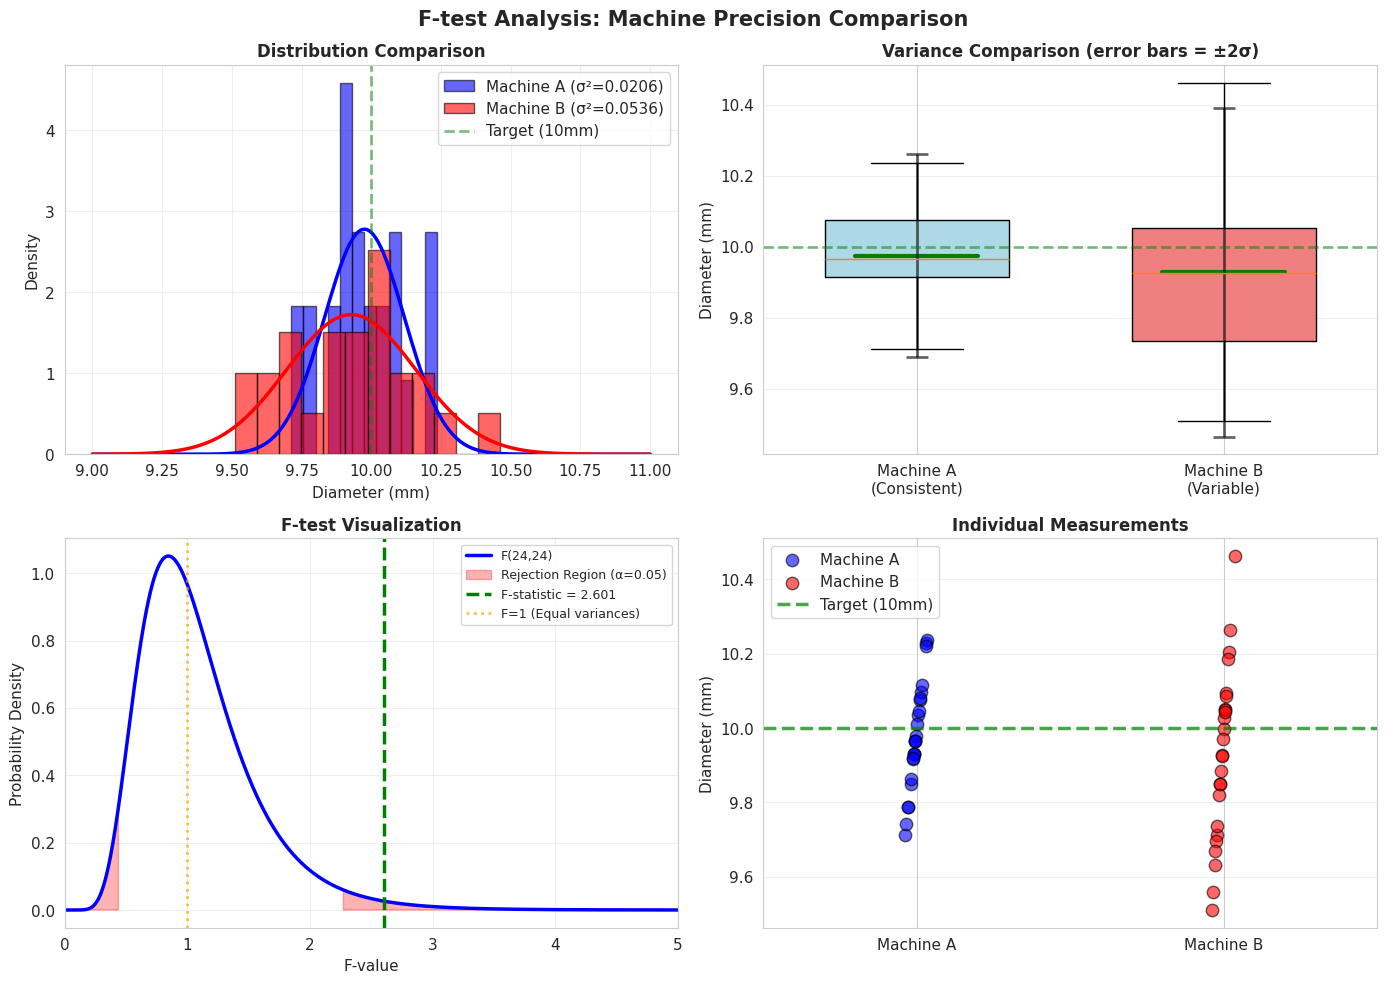

In [ ]:
# Visualization of F-test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution comparison with histograms
ax1 = axes[0, 0]
ax1.hist(machine_a, bins=12, alpha=0.6, label=f'Machine A (σ²={var_a:.4f})',
         color='blue', density=True, edgecolor='black')
ax1.hist(machine_b, bins=12, alpha=0.6, label=f'Machine B (σ²={var_b:.4f})',
         color='red', density=True, edgecolor='black')

# Add normal curves
x_range = np.linspace(9, 11, 200)
ax1.plot(x_range, stats.norm.pdf(x_range, mean_a, std_a), 'b-', linewidth=2.5)
ax1.plot(x_range, stats.norm.pdf(x_range, mean_b, std_b), 'r-', linewidth=2.5)
ax1.axvline(10.0, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Target (10mm)')
ax1.set_xlabel('Diameter (mm)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('Distribution Comparison', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box plots
ax2 = axes[0, 1]
bp = ax2.boxplot([machine_a, machine_b], labels=['Machine A\n(Consistent)', 'Machine B\n(Variable)'],
                  patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

# Add variance visualization
for i, (data, pos) in enumerate(zip([machine_a, machine_b], [1, 2])):
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)
    ax2.plot([pos-0.2, pos+0.2], [mean_val, mean_val], 'g-', linewidth=3)
    ax2.errorbar(pos, mean_val, yerr=2*std_val, fmt='none',
                 capsize=8, capthick=2, color='black', alpha=0.6, linewidth=2)

ax2.set_ylabel('Diameter (mm)', fontsize=11)
ax2.set_title('Variance Comparison (error bars = ±2σ)', fontsize=12, fontweight='bold')
ax2.axhline(10.0, color='green', linestyle='--', alpha=0.5, linewidth=2)
ax2.grid(True, alpha=0.3, axis='y')

# 3. F-distribution
ax3 = axes[1, 0]
x = np.linspace(0.01, 5, 1000)
y = stats.f.pdf(x, df1, df2)
ax3.plot(x, y, 'b-', linewidth=2.5, label=f'F({df1},{df2})')
ax3.fill_between(x, y, where=(x <= f_crit_lower) | (x >= f_crit_upper),
                  alpha=0.3, color='red', label=f'Rejection Region (α={alpha})')
ax3.axvline(f_stat, color='green', linestyle='--', linewidth=2.5,
            label=f'F-statistic = {f_stat:.3f}')
ax3.axvline(1, color='orange', linestyle=':', linewidth=2, alpha=0.7,
            label='F=1 (Equal variances)')
ax3.set_xlabel('F-value', fontsize=11)
ax3.set_ylabel('Probability Density', fontsize=11)
ax3.set_title('F-test Visualization', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 5)

# 4. Scatter plot
ax4 = axes[1, 1]
np.random.seed(42)
jitter_a = np.random.normal(0, 0.02, n_a)
jitter_b = np.random.normal(0, 0.02, n_b)
ax4.scatter(np.ones(n_a) + jitter_a, machine_a,
            alpha=0.6, s=80, label='Machine A', color='blue', edgecolor='black')
ax4.scatter(2*np.ones(n_b) + jitter_b, machine_b,
            alpha=0.6, s=80, label='Machine B', color='red', edgecolor='black')
ax4.axhline(10.0, color='green', linestyle='--', linewidth=2.5,
            alpha=0.7, label='Target (10mm)')
ax4.set_xlim(0.5, 2.5)
ax4.set_xticks([1, 2])
ax4.set_xticklabels(['Machine A', 'Machine B'], fontsize=11)
ax4.set_ylabel('Diameter (mm)', fontsize=11)
ax4.set_title('Individual Measurements', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.suptitle('F-test Analysis: Machine Precision Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 4: Testing Population Proportions

### Moving from Means to Proportions

So far we've focused on **continuous data** (heights, weights, scores). But many important questions involve **categorical data**:

- 🗳️ What percentage of voters support a candidate?
- 🏭 What proportion of parts are defective?
- 📊 What fraction of customers prefer Product A?
- ✅ What percentage of students pass an exam?

### One-Sample Proportion Test

Test whether a population proportion equals a hypothesized value.

**Test Statistic:**

$$z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$$

**Where:**
- $\hat{p}$ = sample proportion
- $p_0$ = hypothesized proportion
- $n$ = sample size

**Important Conditions:**
- ✅ Random sample
- ✅ Large sample: $np_0 \geq 10$ and $n(1-p_0) \geq 10$

---

### Two-Sample Proportion Test

Compare proportions between two groups (A/B testing!)

**Test Statistic:**

$$z = \frac{(\hat{p}_1 - \hat{p}_2) - 0}{\sqrt{\hat{p}_{pooled}(1-\hat{p}_{pooled})(\frac{1}{n_1} + \frac{1}{n_2})}}$$

**Where:**

$$\hat{p}_{pooled} = \frac{x_1 + x_2}{n_1 + n_2}$$


---
### 📊 Example 4: Quality Control - Defect Rate Testing

**Scenario**: A manufacturer claims their defect rate is at most 3%. A quality inspector suspects it's actually higher.

**Question**: Is the actual defect rate significantly higher than 3%?


In [ ]:
print("="*80)
print("SCENARIO: Quality Control - Testing Defect Rate")
print("="*80)
print()
print("A manufacturer claims their defect rate is at most 3%.")
print("We suspect it's actually higher.")
print()

# Sample data
n_inspected = 500
n_defective = 23
p_sample = n_defective / n_inspected
p_claimed = 0.03

print("SAMPLE DATA:")
print("-"*80)
print(f"Items inspected: {n_inspected}")
print(f"Defective items found: {n_defective}")
print(f"Sample proportion: {p_sample:.4f} ({p_sample*100:.2f}%)")
print(f"Claimed proportion: {p_claimed} ({p_claimed*100:.1f}%)")
print()

# Check conditions
print("CHECKING CONDITIONS:")
print(f"  np₀ = {n_inspected * p_claimed:.1f} ≥ 10? {n_inspected * p_claimed >= 10} ✓")
print(f"  n(1-p₀) = {n_inspected * (1-p_claimed):.1f} ≥ 10? {n_inspected * (1-p_claimed) >= 10} ✓")
print("  Conditions met: Large sample test is valid!")
print("="*80)


SCENARIO: Quality Control - Testing Defect Rate

A manufacturer claims their defect rate is at most 3%.
We suspect it's actually higher.

SAMPLE DATA:
--------------------------------------------------------------------------------
Items inspected: 500
Defective items found: 23
Sample proportion: 0.0460 (4.60%)
Claimed proportion: 0.03 (3.0%)

CHECKING CONDITIONS:
  np₀ = 15.0 ≥ 10? True ✓
  n(1-p₀) = 485.0 ≥ 10? True ✓
  Conditions met: Large sample test is valid!


In [ ]:
# Hypothesis Test for Proportion
print("\nHYPOTHESIS TEST: One-Sample Proportion Test")
print("-"*80)
print()

# Step 1: State hypotheses
print("Step 1: State Hypotheses")
print("  H₀: p ≤ 0.03 (Defect rate is at most 3%)")
print("  Hₐ: p > 0.03 (Defect rate is higher than 3%)")
print("  Note: ONE-TAILED test (upper tail)")
print()

# Step 2: Set significance level
alpha = 0.05
print(f"Step 2: Set Significance Level: α = {alpha}")
print()

# Step 3: Calculate test statistic
se = np.sqrt(p_claimed * (1 - p_claimed) / n_inspected)
z_stat = (p_sample - p_claimed) / se

print("Step 3: Calculate Test Statistic")
print(f"  Standard error: {se:.5f}")
print(f"  z-statistic: {z_stat:.3f}")
print()

# Step 4: Calculate p-value (one-tailed, upper)
p_value = 1 - stats.norm.cdf(z_stat)

# Step 4: Make decision
print("Step 4: Make Decision")
print(f"  p-value: {p_value:.4f}")

if p_value < alpha:
    print(f"  Decision: REJECT H₀ (p = {p_value:.4f} < α = {alpha})")
    print("  Conclusion: Defect rate IS significantly higher than 3%! ⚠️")
    print("  Action: Investigate manufacturing process immediately")
else:
    print(f"  Decision: FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print("  Conclusion: No significant evidence of increased defect rate")

# Confidence interval
z_crit = stats.norm.ppf(1 - alpha/2)
margin_error = z_crit * np.sqrt(p_sample * (1 - p_sample) / n_inspected)
ci_lower = p_sample - margin_error
ci_upper = p_sample + margin_error

print()
print(f"95% Confidence Interval for true defect rate:")
print(f"  ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"  ({ci_lower*100:.2f}%, {ci_upper*100:.2f}%)")
print("="*80)



HYPOTHESIS TEST: One-Sample Proportion Test
--------------------------------------------------------------------------------

Step 1: State Hypotheses
  H₀: p ≤ 0.03 (Defect rate is at most 3%)
  Hₐ: p > 0.03 (Defect rate is higher than 3%)
  Note: ONE-TAILED test (upper tail)

Step 2: Set Significance Level: α = 0.05

Step 3: Calculate Test Statistic
  Standard error: 0.00763
  z-statistic: 2.097

Step 4: Make Decision
  p-value: 0.0180
  Decision: REJECT H₀ (p = 0.0180 < α = 0.05)
  Conclusion: Defect rate IS significantly higher than 3%! ⚠️
  Action: Investigate manufacturing process immediately

95% Confidence Interval for true defect rate:
  (0.0276, 0.0644)
  (2.76%, 6.44%)


---
### 📊 Example 5: A/B Testing - Click-Through Rates

**Scenario**: A company wants to test if a new marketing campaign (Campaign B) performs better than the old one (Campaign A).

**Question**: Is there a significant difference in click-through rates?


In [ ]:
print("="*80)
print("SCENARIO: Comparing Click-Through Rates (A/B Testing)")
print("="*80)
print()

# Sample data for two campaigns
np.random.seed(42)

# Campaign A (old)
n_a = 1000
clicks_a = 85
p_a = clicks_a / n_a

# Campaign B (new)
n_b = 1000
clicks_b = 112
p_b = clicks_b / n_b

print("CAMPAIGN RESULTS:")
print("-"*80)
print(f"Campaign A (Old):")
print(f"  Visitors: {n_a:,}")
print(f"  Clicks: {clicks_a}")
print(f"  Click rate: {p_a:.4f} ({p_a*100:.2f}%)")
print()
print(f"Campaign B (New):")
print(f"  Visitors: {n_b:,}")
print(f"  Clicks: {clicks_b}")
print(f"  Click rate: {p_b:.4f} ({p_b*100:.2f}%)")
print()
print(f"Difference: {(p_b - p_a)*100:.2f} percentage points")
print(f"Relative improvement: {((p_b - p_a) / p_a) * 100:.1f}%")
print("="*80)


SCENARIO: Comparing Click-Through Rates (A/B Testing)

CAMPAIGN RESULTS:
--------------------------------------------------------------------------------
Campaign A (Old):
  Visitors: 1,000
  Clicks: 85
  Click rate: 0.0850 (8.50%)

Campaign B (New):
  Visitors: 1,000
  Clicks: 112
  Click rate: 0.1120 (11.20%)

Difference: 2.70 percentage points
Relative improvement: 31.8%


In [ ]:
# Two-proportion z-test
print("\nHYPOTHESIS TEST: Two-Sample Proportion Test")
print("-"*80)
print()

print("Step 1: State Hypotheses")
print("  H₀: p_A = p_B (No difference in click rates)")
print("  Hₐ: p_A ≠ p_B (Click rates are different)")
print()

alpha = 0.05
print(f"Step 2: Set Significance Level: α = {alpha}")
print()

# Pooled proportion
p_pooled = (clicks_a + clicks_b) / (n_a + n_b)
se_diff = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_a + 1/n_b))
z_stat = (p_b - p_a) / se_diff
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("Step 3: Calculate Test Statistic")
print(f"  Pooled proportion: {p_pooled:.4f}")
print(f"  Standard error: {se_diff:.5f}")
print(f"  z-statistic: {z_stat:.3f}")
print()

print("Step 4: Make Decision")
print(f"  p-value: {p_value:.4f}")

if p_value < alpha:
    print(f"  Decision: REJECT H₀ (p = {p_value:.4f} < α = {alpha})")
    print("  Conclusion: Campaign B has a significantly different click rate! ✓")
    improvement = ((p_b - p_a) / p_a) * 100
    print(f"  Campaign B shows a {improvement:.1f}% improvement over Campaign A")
    print("  Recommendation: Implement Campaign B!")
else:
    print(f"  Decision: FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print("  Conclusion: No significant difference between campaigns")

# Confidence interval for difference
z_crit = stats.norm.ppf(1 - alpha/2)
se_ci = np.sqrt((p_a * (1-p_a) / n_a) + (p_b * (1-p_b) / n_b))
margin = z_crit * se_ci
ci_lower = (p_b - p_a) - margin
ci_upper = (p_b - p_a) + margin

print()
print(f"95% CI for difference in proportions:")
print(f"  ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"  ({ci_lower*100:.2f}%, {ci_upper*100:.2f}%)")
print("="*80)



HYPOTHESIS TEST: Two-Sample Proportion Test
--------------------------------------------------------------------------------

Step 1: State Hypotheses
  H₀: p_A = p_B (No difference in click rates)
  Hₐ: p_A ≠ p_B (Click rates are different)

Step 2: Set Significance Level: α = 0.05

Step 3: Calculate Test Statistic
  Pooled proportion: 0.0985
  Standard error: 0.01333
  z-statistic: 2.026

Step 4: Make Decision
  p-value: 0.0428
  Decision: REJECT H₀ (p = 0.0428 < α = 0.05)
  Conclusion: Campaign B has a significantly different click rate! ✓
  Campaign B shows a 31.8% improvement over Campaign A
  Recommendation: Implement Campaign B!

95% CI for difference in proportions:
  (0.0009, 0.0531)
  (0.09%, 5.31%)


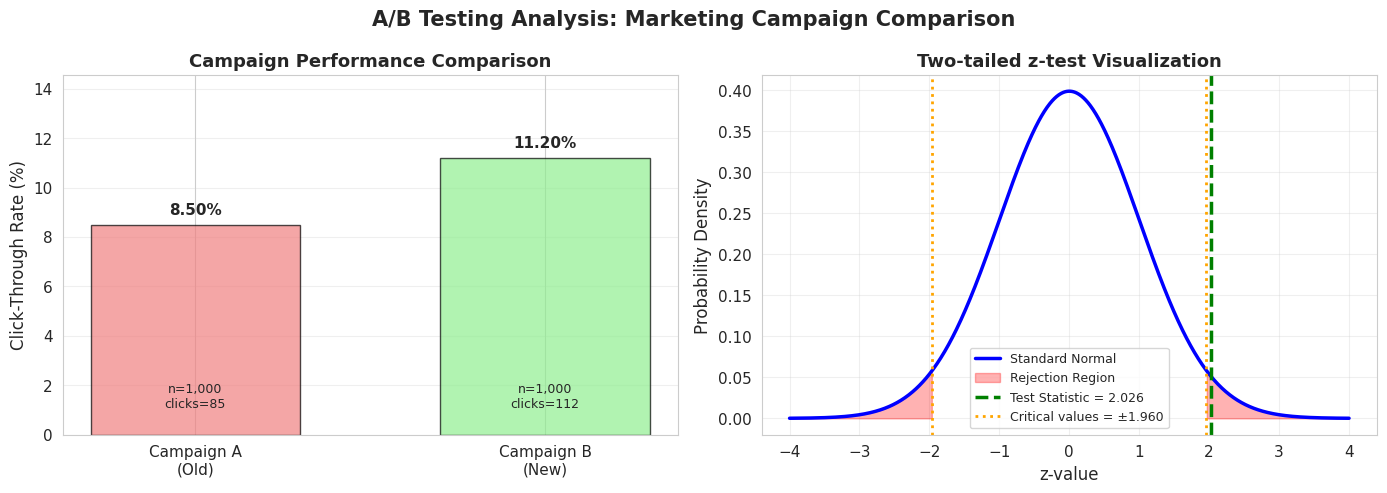

In [ ]:
# Visualization for A/B Testing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar chart comparing click rates
ax1 = axes[0]
campaigns = ['Campaign A\n(Old)', 'Campaign B\n(New)']
rates = [p_a * 100, p_b * 100]
colors = ['lightcoral', 'lightgreen']
bars = ax1.bar(campaigns, rates, color=colors, alpha=0.7, edgecolor='black', width=0.6)
ax1.set_ylabel('Click-Through Rate (%)', fontsize=12)
ax1.set_title('Campaign Performance Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(rates) * 1.3)

# Add value labels
for i, (bar, rate) in enumerate(zip(bars, rates)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.3,
            f'{rate:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add sample sizes
for i, (bar, n, clicks) in enumerate(zip(bars, [n_a, n_b], [clicks_a, clicks_b])):
    ax1.text(bar.get_x() + bar.get_width()/2., 1,
            f'n={n:,}\nclicks={clicks}',
            ha='center', va='bottom', fontsize=9)

ax1.grid(True, alpha=0.3, axis='y')

# 2. Standard normal distribution with test statistic
ax2 = axes[1]
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
ax2.plot(x, y, 'b-', linewidth=2.5, label='Standard Normal')

z_crit_val = stats.norm.ppf(1 - alpha/2)
ax2.fill_between(x, y, where=(x <= -z_crit_val), alpha=0.3, color='red', label='Rejection Region')
ax2.fill_between(x, y, where=(x >= z_crit_val), alpha=0.3, color='red')
ax2.axvline(z_stat, color='green', linestyle='--', linewidth=2.5,
            label=f'Test Statistic = {z_stat:.3f}')
ax2.axvline(-z_crit_val, color='orange', linestyle=':', linewidth=2)
ax2.axvline(z_crit_val, color='orange', linestyle=':', linewidth=2,
            label=f'Critical values = ±{z_crit_val:.3f}')
ax2.set_xlabel('z-value', fontsize=12)
ax2.set_ylabel('Probability Density', fontsize=12)
ax2.set_title('Two-tailed z-test Visualization', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('A/B Testing Analysis: Marketing Campaign Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 5: Chi-Square Test of Independence

### Testing Relationships Between Categorical Variables

The chi-square test answers: **Are two categorical variables related?**

### Examples:

- 🎓 Is there a relationship between **campus** and **major choice**?
- 🎬 Does **age group** affect **movie genre preference**?
- 🏥 Is **smoking status** related to **disease occurrence**?
- 📱 Does **device type** influence **purchase behavior**?

---

### The Chi-Square Statistic

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

**Where:**
- $O$ = Observed frequency
- $E$ = Expected frequency (if variables were independent)

**How It Works:**

1. Calculate **expected frequencies** assuming independence:
   $$E_{ij} = \frac{(\text{Row Total}_i) \times (\text{Column Total}_j)}{\text{Grand Total}}$$

2. Compare observed vs expected
3. Large differences → Large $\chi^2$ → Evidence of relationship

**Degrees of Freedom:**

$$df = (\text{number of rows} - 1) \times (\text{number of columns} - 1)$$

---

### Hypothesis Framework

**Step 1: Hypotheses**
- $H_0$: The two variables are **independent** (no relationship)
- $H_a$: The two variables are **related** (dependent)

**Step 2: Decision Rule**
- Large $\chi^2$ → Small p-value → Reject $H_0$ (relationship exists)
- Small $\chi^2$ → Large p-value → Fail to reject $H_0$ (no relationship)

**Effect Size: Cramér's V**

$$V = \sqrt{\frac{\chi^2}{n \times \min(r-1, c-1)}}$$

- $V < 0.1$: Negligible association
- $0.1 \leq V < 0.3$: Small association
- $0.3 \leq V < 0.5$: Medium association
- $V \geq 0.5$: Large association

### Standardized Residuals: Where Is the Association?

While χ² tells us **if** a relationship exists and Cramér's V tells us **how strong** it is, **standardized residuals** tell us **where** the association is coming from.

**Standardized Residual Formula:**

$$r_{ij} = \frac{O_{ij} - E_{ij}}{\sqrt{E_{ij}}}$$

**Where:**
- $O_{ij}$ = Observed frequency in cell (i, j)
- $E_{ij}$ = Expected frequency in cell (i, j)

**Interpretation Guide:**

| Standardized Residual | Meaning |
|----------------------|---------|
| $\|r\| > 3$ | **Very strong** deviation from independence |
| $\|r\| > 2$ | **Significant** deviation (contributes to χ²) |
| $-2 \leq r \leq 2$ | Within expected range |
| $r > 0$ | **More** observations than expected |
| $r < 0$ | **Fewer** observations than expected |


---
### 📊 Example 6: Campus and Major Preference

**Scenario**: A university administrator wants to know if there's a relationship between home campus and the major students choose.

**Question**: Is major choice independent of campus?


In [ ]:
print("="*80)
print("SCENARIO: Is There a Relationship Between Campus and Major Choice?")
print("="*80)
print()

# Create contingency table
# Rows: Campus (Pilani, Hyderabad)
# Columns: Major (CS, Mechanical, EE)

observed = np.array([
    [120, 80, 50],   # Pilani
    [90, 110, 80]    # Hyderabad
])

campuses = ['Pilani', 'Hyderabad']
majors = ['CS', 'Mechanical', 'EE']

# Create DataFrame
df_observed = pd.DataFrame(observed, index=campuses, columns=majors)
df_observed['Total'] = df_observed.sum(axis=1)
df_observed.loc['Total'] = df_observed.sum()

print("OBSERVED FREQUENCIES:")
print("-"*80)
print(df_observed)
print()

# Calculate totals
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)
grand_total = observed.sum()

print("MARGINAL TOTALS:")
print(f"  Pilani total: {row_totals[0]}")
print(f"  Hyderabad total: {row_totals[1]}")
print(f"  CS total: {col_totals[0]}")
print(f"  Mechanical total: {col_totals[1]}")
print(f"  EE total: {col_totals[2]}")
print(f"  Grand total: {grand_total}")
print("="*80)


SCENARIO: Is There a Relationship Between Campus and Major Choice?

OBSERVED FREQUENCIES:
--------------------------------------------------------------------------------
            CS  Mechanical   EE  Total
Pilani     120          80   50    250
Hyderabad   90         110   80    280
Total      210         190  130    530

MARGINAL TOTALS:
  Pilani total: 250
  Hyderabad total: 280
  CS total: 210
  Mechanical total: 190
  EE total: 130
  Grand total: 530


In [ ]:
# Calculate Expected Frequencies
print("\nEXPECTED FREQUENCIES (if independent):")
print("-"*80)

# Expected frequencies
expected = np.outer(row_totals, col_totals) / grand_total

df_expected = pd.DataFrame(expected, index=campuses, columns=majors)
df_expected['Total'] = df_expected.sum(axis=1)
df_expected.loc['Total'] = df_expected.sum()
print(df_expected.round(2))
print()

print("HOW EXPECTED FREQUENCIES ARE CALCULATED:")
print("  E_ij = (Row Total_i × Column Total_j) / Grand Total")
print(f"  Example: E_Pilani,CS = ({row_totals[0]} × {col_totals[0]}) / {grand_total} = {expected[0,0]:.2f}")
print("="*80)



EXPECTED FREQUENCIES (if independent):
--------------------------------------------------------------------------------
               CS  Mechanical      EE  Total
Pilani      99.06       89.62   61.32  250.0
Hyderabad  110.94      100.38   68.68  280.0
Total      210.00      190.00  130.00  530.0

HOW EXPECTED FREQUENCIES ARE CALCULATED:
  E_ij = (Row Total_i × Column Total_j) / Grand Total
  Example: E_Pilani,CS = (250 × 210) / 530 = 99.06


In [ ]:
# Perform Chi-Square Test
print("\nHYPOTHESIS TEST: Chi-Square Test of Independence")
print("-"*80)
print()

# Step 1: State hypotheses
print("Step 1: State Hypotheses")
print("  H₀: Campus and Major choice are INDEPENDENT")
print("  Hₐ: Campus and Major choice are RELATED (dependent)")
print()

# Step 2: Set significance level
alpha = 0.05
print(f"Step 2: Set Significance Level: α = {alpha}")
print()

# Step 3: Calculate chi-square statistic
chi2_stat, p_value, dof, expected_freq = stats.chi2_contingency(observed)

print("Step 3: Calculate Test Statistic")
print(f"  χ² statistic: {chi2_stat:.3f}")
print(f"  Degrees of freedom: {dof}")
print(f"    df = (rows - 1) × (columns - 1) = ({len(campuses)} - 1) × ({len(majors)} - 1) = {dof}")
print()

# Step 4: Make decision
print("Step 4: Make Decision")
print(f"  p-value: {p_value:.4f}")

if p_value < alpha:
    print(f"  Decision: REJECT H₀ (p = {p_value:.4f} < α = {alpha})")
    print("  Conclusion: There IS a significant relationship between campus and major! ✓")
else:
    print(f"  Decision: FAIL TO REJECT H₀ (p = {p_value:.4f} ≥ α = {alpha})")
    print("  Conclusion: No significant relationship between campus and major")

# Calculate Cramér's V (effect size)
n = grand_total
min_dim = min(len(campuses) - 1, len(majors) - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))

print()
print(f"Effect Size (Cramér's V): {cramers_v:.3f}")
if cramers_v < 0.1:
    effect = "negligible"
elif cramers_v < 0.3:
    effect = "small"
elif cramers_v < 0.5:
    effect = "medium"
else:
    effect = "large"
print(f"Interpretation: {effect.upper()} association")
print()

# Standardized residuals
residuals = (observed - expected) / np.sqrt(expected)
print("STANDARDIZED RESIDUALS:")
print("  (Shows which cells contribute most to chi-square)")
df_residuals = pd.DataFrame(residuals, index=campuses, columns=majors)
print(df_residuals.round(2))
print("  |residual| > 2 suggests significant deviation from independence")
print("="*80)



HYPOTHESIS TEST: Chi-Square Test of Independence
--------------------------------------------------------------------------------

Step 1: State Hypotheses
  H₀: Campus and Major choice are INDEPENDENT
  Hₐ: Campus and Major choice are RELATED (dependent)

Step 2: Set Significance Level: α = 0.05

Step 3: Calculate Test Statistic
  χ² statistic: 14.293
  Degrees of freedom: 2
    df = (rows - 1) × (columns - 1) = (2 - 1) × (3 - 1) = 2

Step 4: Make Decision
  p-value: 0.0008
  Decision: REJECT H₀ (p = 0.0008 < α = 0.05)
  Conclusion: There IS a significant relationship between campus and major! ✓

Effect Size (Cramér's V): 0.164
Interpretation: SMALL association

STANDARDIZED RESIDUALS:
  (Shows which cells contribute most to chi-square)
             CS  Mechanical    EE
Pilani     2.10       -1.02 -1.45
Hyderabad -1.99        0.96  1.37
  |residual| > 2 suggests significant deviation from independence


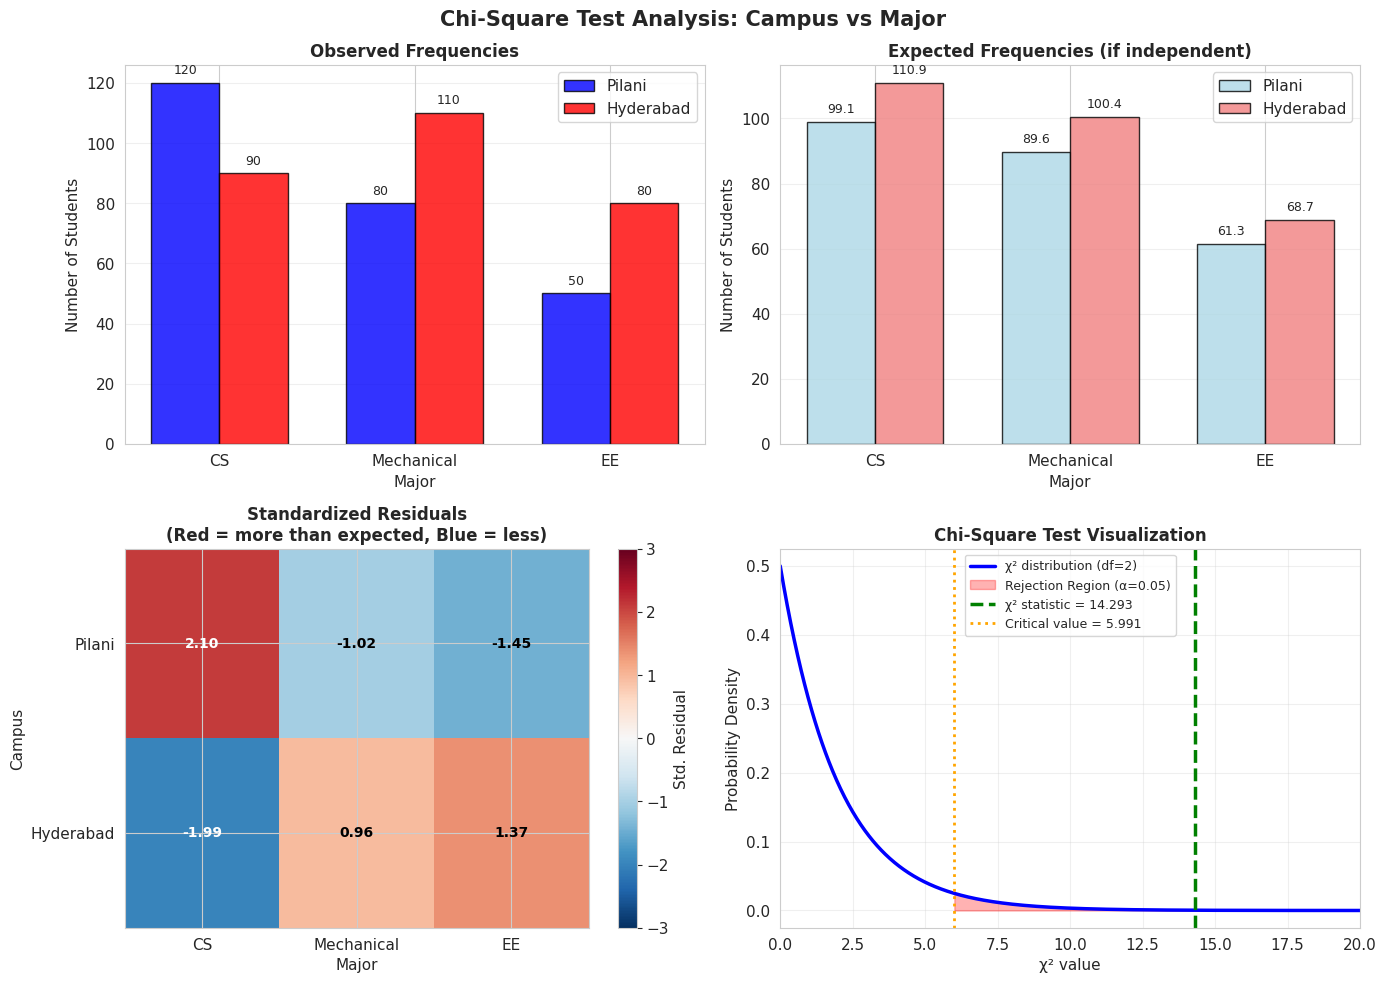

In [ ]:
# Visualization of Chi-Square Test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Grouped bar chart - Observed
ax1 = axes[0, 0]
x = np.arange(len(majors))
width = 0.35
bars1 = ax1.bar(x - width/2, observed[0], width, label='Pilani',
                alpha=0.8, color='blue', edgecolor='black')
bars2 = ax1.bar(x + width/2, observed[1], width, label='Hyderabad',
                alpha=0.8, color='red', edgecolor='black')
ax1.set_xlabel('Major', fontsize=11)
ax1.set_ylabel('Number of Students', fontsize=11)
ax1.set_title('Observed Frequencies', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(majors)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 2. Grouped bar chart - Expected
ax2 = axes[0, 1]
bars3 = ax2.bar(x - width/2, expected[0], width, label='Pilani',
                alpha=0.8, color='lightblue', edgecolor='black')
bars4 = ax2.bar(x + width/2, expected[1], width, label='Hyderabad',
                alpha=0.8, color='lightcoral', edgecolor='black')
ax2.set_xlabel('Major', fontsize=11)
ax2.set_ylabel('Number of Students', fontsize=11)
ax2.set_title('Expected Frequencies (if independent)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(majors)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# 3. Heatmap of standardized residuals
ax3 = axes[1, 0]
im = ax3.imshow(residuals, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
ax3.set_xticks(range(len(majors)))
ax3.set_xticklabels(majors)
ax3.set_yticks(range(len(campuses)))
ax3.set_yticklabels(campuses)
ax3.set_xlabel('Major', fontsize=11)
ax3.set_ylabel('Campus', fontsize=11)
ax3.set_title('Standardized Residuals\n(Red = more than expected, Blue = less)',
              fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(campuses)):
    for j in range(len(majors)):
        text_color = "white" if abs(residuals[i, j]) > 1.5 else "black"
        ax3.text(j, i, f'{residuals[i, j]:.2f}',
                ha="center", va="center", color=text_color, fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax3, label='Std. Residual')

# 4. Chi-square distribution
ax4 = axes[1, 1]
x_chi = np.linspace(0, 20, 1000)
y_chi = stats.chi2.pdf(x_chi, dof)
ax4.plot(x_chi, y_chi, 'b-', linewidth=2.5, label=f'χ² distribution (df={dof})')

chi2_crit = stats.chi2.ppf(1 - alpha, dof)
ax4.fill_between(x_chi, y_chi, where=(x_chi >= chi2_crit), alpha=0.3, color='red',
                  label=f'Rejection Region (α={alpha})')
ax4.axvline(chi2_stat, color='green', linestyle='--', linewidth=2.5,
            label=f'χ² statistic = {chi2_stat:.3f}')
ax4.axvline(chi2_crit, color='orange', linestyle=':', linewidth=2,
            label=f'Critical value = {chi2_crit:.3f}')
ax4.set_xlabel('χ² value', fontsize=11)
ax4.set_ylabel('Probability Density', fontsize=11)
ax4.set_title('Chi-Square Test Visualization', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 20)

plt.suptitle('Chi-Square Test Analysis: Campus vs Major',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🌳 Decision Tree: Choosing the Right Test

Use this flowchart to select the appropriate statistical test:

```
What type of data do you have?
│
├─ CONTINUOUS (measurements, scores, etc.)
│  │
│  ├─ Comparing ONE group to a value
│  │  └─ → One-sample t-test
│  │
│  ├─ Comparing TWO groups
│  │  │
│  │  ├─ Are samples INDEPENDENT?
│  │  │  └─ → Welch's two-sample t-test
│  │  │
│  │  └─ Are samples PAIRED (same subjects)?
│  │     └─ → Paired t-test
│  │
│  └─ Comparing VARIANCES of two groups
│     └─ → F-test
│
└─ CATEGORICAL (counts, proportions, yes/no)
   │
   ├─ Testing ONE proportion
   │  └─ → One-sample z-test for proportion
   │
   ├─ Comparing TWO proportions
   │  └─ → Two-sample z-test for proportion
   │
   └─ Testing RELATIONSHIP between categories
      └─ → Chi-square test of independence
```

---

### Quick Reference Table

| Scenario | Test | When to Use |
|----------|------|-------------|
| Compare two group means (independent) | **Welch's t-test** | Separate groups, continuous data |
| Compare two measurements (same subjects) | **Paired t-test** | Before-after, matched pairs |
| Compare two variances | **F-test** | Testing consistency/precision |
| Test one proportion | **z-test** | Single categorical outcome |
| Compare two proportions | **Two-sample z-test** | A/B testing, two groups |
| Test categorical relationship | **Chi-square test** | Contingency table analysis |


---
## 📚 Summary and Key Takeaways

### What We Learned in Week 4

We've expanded our statistical toolkit to handle real-world scenarios involving multiple groups and categorical data:

#### 1. **Comparing Two Means**

**Independent Samples (Welch's t-test):**
- ✅ Default choice - no equal variance assumption needed
- ✅ More robust and reliable
- ✅ Use when comparing separate, unrelated groups

**Paired Samples:**
- ✅ Same subjects measured twice
- ✅ More powerful (controls for individual variation)
- ✅ Use for before-after studies

#### 2. **Comparing Variances (F-test)**
- Tests consistency and precision
- Critical for quality control
- Ratio of variances: large F → significant difference

#### 3. **Testing Proportions**
- One-sample: Compare to hypothesized value
- Two-sample: A/B testing, comparing groups
- Use z-test (normal approximation)

#### 4. **Chi-Square Test**
- Tests relationships between categorical variables
- Compare observed vs expected frequencies
- Use Cramér's V for effect size

---

### Key Formulas Reference

| Test | Formula | df |
|------|---------|-----|
| **Welch's t-test** | $t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$ | Welch-Satterthwaite |
| **Paired t-test** | $t = \frac{\bar{d}}{s_d/\sqrt{n}}$ | $n-1$ |
| **F-test** | $F = \frac{s_1^2}{s_2^2}$ | $(n_1-1, n_2-1)$ |
| **Proportion (1)** | $z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$ | N/A |
| **Proportion (2)** | $z = \frac{\hat{p}_1 - \hat{p}_2}{SE_{pooled}}$ | N/A |
| **Chi-square** | $\chi^2 = \sum\frac{(O-E)^2}{E}$ | $(r-1)(c-1)$ |

---

### Best Practices

1. **Always check assumptions:**
   - ✓ Normality (for small samples)
   - ✓ Independence of observations
   - ✓ Sample size requirements

2. **Report effect sizes:**
   - Cohen's d for mean differences
   - Cramér's V for chi-square
   - Don't just report p-values!

3. **Visualize your data:**
   - Box plots for group comparisons
   - Scatter plots for paired data
   - Bar charts for proportions

4. **Interpret in context:**
   - Statistical significance ≠ practical importance
   - Consider confidence intervals
   - Think about real-world implications

---

### 🎯 Congratulations!

You've mastered the essential tools for:
- ✅ Comparing populations
- ✅ Analyzing categorical data
- ✅ Making data-driven decisions

These methods form the foundation of experimental design, A/B testing, and survey analysis.

**Keep practicing and stay curious!** 📊🚀


---
## 🎯 Practice Exercises

### Exercise 1: Independent t-test

**Task:** A company wants to compare productivity (units per hour) between two factories.

```python
factory_a = np.array([45, 48, 43, 47, 49, 44, 46, 48, 45, 47])
factory_b = np.array([42, 40, 43, 41, 39, 42, 40, 41, 43, 38])
```

Complete:
1. Calculate descriptive statistics
2. Perform Welch's t-test
3. Create visualizations
4. Interpret results

---

### Exercise 2: Paired t-test

**Task:** Test if a new study technique improves test scores.

```python
before_scores = np.array([65, 70, 68, 72, 67, 69, 71, 66, 73, 68])
after_scores = np.array([68, 74, 70, 75, 71, 72, 73, 69, 77, 72])
```

Complete:
1. Calculate differences
2. Perform paired t-test
3. Calculate effect size
4. Write a brief report

---

### Exercise 3: F-test

**Task:** Compare consistency of two temperature sensors.

```python
sensor_a = np.array([22.1, 22.3, 22.0, 22.2, 22.1, 22.4, 22.2, 22.1])
sensor_b = np.array([22.5, 21.8, 22.9, 21.5, 23.1, 21.9, 22.7, 21.6])
```

Complete:
1. Calculate variances
2. Perform F-test
3. Which sensor is more reliable?

---

### Exercise 4: Chi-Square Test

**Task:** Test relationship between exercise frequency and stress level.

```python
# Contingency table: rows=exercise, columns=stress
#                    Low  Medium  High
exercise_stress = [[25,   15,    10],   # Regular
                   [15,   20,    15],   # Occasional
                   [5,    15,    30]]   # None
```

Complete:
1. Calculate expected frequencies
2. Perform chi-square test
3. Calculate Cramér's V
4. Interpret results
